# v1.0.4 Multidemic Symbolic **Logistic Regression** (binary classification)

Geppy GEP-RNC with multi-objective fitness via the **HFF** Rust library
(`hff.calculate_fitness_hf1_enhanced`), evaluated across a stratified
train / validation / holdout split. Output goes through a sigmoid to produce
probabilities; an optimal decision threshold is found via the J-statistic.

Companion notebook to `v1.0.4_Multidemic_SymbolicLinearRegression.ipynb`.
Shares `hff_geppy_helpers.py`.

The island loop in section 3.3 is verbatim from v1.0.3_Multidemic — the
tested working multidemic pattern.

## Prerequisites

Build HFF into the active env:

```bash
cd /path/to/hff
maturin develop --release
```

# 0. Tools and Dependencies

In [1]:
import sys
sys.path.insert(0, ".")  # ensure local helpers importable

import datetime
import math
import operator
import os
import random

import geppy as gep
import numpy as np
import pandas as pd
import multiprocess as mp

from deap import creator, base, tools
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, precision_score, recall_score, classification_report,
    precision_recall_curve,
)

import hff
import hff_geppy_helpers as hgh

print(f"hff library OK (test fitness: {hgh.hff_fitness_classification([0.9]*5)})")

hff library OK (test fitness: (1.3796341802638372,))


### Reproducibility & settings

In [2]:
settings = hgh.GeppySettings(
    seed=5,
    # Splits
    train_frac=0.60,
    val_frac=0.20,
    holdout_frac=0.20,
    # Genes
    head_length=12,
    n_genes=6,
    rnc_array_length=10,
    # Evolution
    n_gen=200,
    population_size=200,
    tournament_size=4,
    num_elites=2,
    num_islands=3,
    migration_freq=40,
    k_migrants=3,
    # HOF
    champs=30,
    # Multiprocessing
    procs=8,
    # Fitness shape
    complexity_cap=500.0,
    enable_linear_scaling=True,
    # >>> THE KEY KNOB for the GECCO paper's A/B story <<<
    # Both notebooks default to "truenorth": pole at the origin in an
    # augmented space. Selects for absolute minimisation of every objective
    # (or, equivalently for classification, maximisation of the "perfect"
    # signal). Switch to "balanced" to compare against direction-only
    # selection where any magnitude with equal coordinates sits on the pole.
    north_pole_method="truenorth",
)

random.seed(settings.seed)
np.random.seed(settings.seed)

experiment = {
    "date": datetime.datetime.now().strftime("%Y/%m/%d"),
    "seed": str(settings.seed),
    "task": "binary classification",
    "north_pole_method": settings.north_pole_method,
}

# 1. Data

Default dataset is **UCI Heart Disease (Cleveland)** — 303 rows × 13
features, binary target. We drop 6 rows with missing values to get 297 rows.
Small + noisy — a sharp overfit-risk test bed where the val-aware HFF
fitness should outperform single-objective MSE.

## 1.1 Fetch + dictionary

In [3]:
yourDataDir = "data/"
heart_csv = os.path.join(yourDataDir, "heart_cleveland.csv")

# Column names per the UCI documentation
HEART_COLS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num",
]

if not os.path.exists(heart_csv):
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
    print(f"Fetching Heart Disease (Cleveland) from {url} ...")
    raw = pd.read_csv(url, header=None, names=HEART_COLS, na_values="?")
    os.makedirs(yourDataDir, exist_ok=True)
    raw.to_csv(heart_csv, index=False)
    print(f"Saved {len(raw)} rows to {heart_csv}")
else:
    raw = pd.read_csv(heart_csv)
    print(f"Loaded {len(raw)} rows from {heart_csv}")

# Drop missing rows (the dataset uses "?" in `ca` and `thal`)
raw = raw.dropna().reset_index(drop=True)
print(f"After dropna: {len(raw)} rows")

# Binarise the target: num=0 is "no disease", num>=1 is "disease"
raw["target"] = (raw["num"] > 0).astype(int)
yourData = raw.drop(columns=["num"])
print(f"Target balance: {yourData['target'].value_counts().to_dict()}")

Loaded 303 rows from data/heart_cleveland.csv
After dropna: 297 rows
Target balance: {0: 160, 1: 137}


## 1.2 Dictionary

In [4]:
HEART_DESCRIPTIONS = {
    "age":      "Age in years",
    "sex":      "Sex (1 = male, 0 = female)",
    "cp":       "Chest pain type (1..4)",
    "trestbps": "Resting blood pressure (mm Hg)",
    "chol":     "Serum cholesterol (mg/dl)",
    "fbs":      "Fasting blood sugar > 120 mg/dl (1=true)",
    "restecg":  "Resting ECG results (0..2)",
    "thalach":  "Max heart rate achieved",
    "exang":    "Exercise-induced angina (1=yes)",
    "oldpeak":  "ST depression vs rest",
    "slope":    "ST segment slope (1..3)",
    "ca":       "Number of major vessels coloured by fluoroscopy",
    "thal":     "Thal: 3=normal, 6=fixed defect, 7=reversible defect",
}
rows = []
for i, col in enumerate(yourData.columns):
    if col == "target":
        rows.append({"Field": i + 1, "Symbol": col, "Type": "Target",
                     "Description": "1 = heart disease present, 0 = absent"})
    else:
        rows.append({"Field": i + 1, "Symbol": col, "Type": "Input",
                     "Description": HEART_DESCRIPTIONS.get(col, col)})
yourDictionary = pd.DataFrame(rows)
yourDictionary.head(20)

,Field,Symbol,Type,Description
0,1,age,Input,Age in years
1,2,sex,Input,"Sex (1 = male, 0 = female)"
2,3,cp,Input,Chest pain type (1..4)
3,4,trestbps,Input,Resting blood pressure (mm Hg)
4,5,chol,Input,Serum cholesterol (mg/dl)
5,6,fbs,Input,Fasting blood sugar > 120 mg/dl (1=true)
6,7,restecg,Input,Resting ECG results (0..2)
7,8,thalach,Input,Max heart rate achieved
8,9,exang,Input,Exercise-induced angina (1=yes)
9,10,oldpeak,Input,ST depression vs rest


In [5]:
yourSymbols = yourData.columns.tolist()
finalTerminals = yourDictionary.loc[yourDictionary["Type"] == "Input"].sort_values("Field")["Symbol"].tolist()
finalTarget = yourDictionary.loc[yourDictionary["Type"] == "Target"].sort_values("Field")["Symbol"].tolist()
target_col = finalTarget[0]
print(f"Inputs ({len(finalTerminals)}): {finalTerminals}")
print(f"Target: {target_col}")

Inputs (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target: target


## 1.3 Stratified train / validation / holdout split

Simple stratified random split — 60% train / 20% validation / 20% holdout,
preserving the target balance in each.

In [6]:
from sklearn.model_selection import train_test_split

train_val, holdout = train_test_split(
    yourData,
    test_size=settings.holdout_frac,
    stratify=yourData[target_col],
    random_state=settings.seed,
)
# Carve validation out of the remaining train_val pool
val_frac_of_remaining = settings.val_frac / (settings.train_frac + settings.val_frac)
train, validation = train_test_split(
    train_val,
    test_size=val_frac_of_remaining,
    stratify=train_val[target_col],
    random_state=settings.seed,
)
train = train.reset_index(drop=True)
validation = validation.reset_index(drop=True)
holdout = holdout.reset_index(drop=True)

print(f"train: {len(train)}  pos: {int(train[target_col].sum())}")
print(f"val:   {len(validation)}  pos: {int(validation[target_col].sum())}")
print(f"hold:  {len(holdout)}  pos: {int(holdout[target_col].sum())}")
experiment["splits"] = {"train": len(train), "validation": len(validation), "holdout": len(holdout)}

train: 177  pos: 81
val:   60  pos: 28
hold:  60  pos: 28


## 1.4 Quick EDA

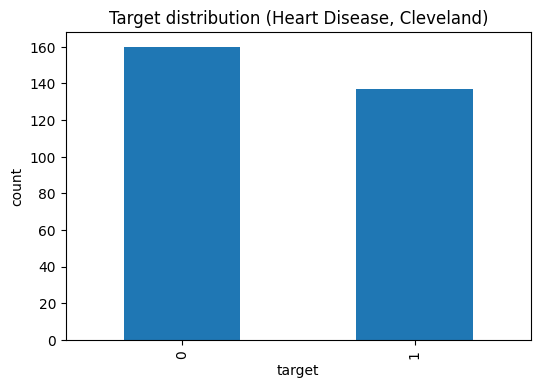

In [7]:
plt.figure(figsize=(6, 4))
yourData[target_col].value_counts().plot(kind="bar")
plt.title("Target distribution (Heart Disease, Cleveland)")
plt.xlabel(target_col)
plt.ylabel("count")
plt.show()

# 2. Design

## 2.1 Primitive set + globals

In [8]:
pset = gep.PrimitiveSet("Main", input_names=finalTerminals)

pset.add_function(operator.add, 2)
pset.add_function(operator.sub, 2)
pset.add_function(operator.mul, 2)
pset.add_function(hgh.protected_div_zero, 2)
# Classification-friendly extras:
pset.add_function(hgh.safe_max, 2)
pset.add_function(hgh.safe_min, 2)

pset.add_rnc_terminal()
experiment["final_terminal_inputs"] = finalTerminals

# Expose terminals + target as module-level globals for geppy's lambdas
for term in finalTerminals:
    globals()[term] = train[term].values
Y = train[target_col].values

## 2.2 Fitness, genes, toolbox

In [9]:
creator.create("FitnessMin", base.Fitness, weights=(-1,))
creator.create("Individual", gep.Chromosome, fitness=creator.FitnessMin)

toolbox = gep.Toolbox()
toolbox.register("rnc_gen", random.randint, a=settings.rnc_lo, b=settings.rnc_hi)
toolbox.register(
    "gene_gen", gep.GeneDc,
    pset=pset, head_length=settings.head_length,
    rnc_gen=toolbox.rnc_gen, rnc_array_length=settings.rnc_array_length,
)
if settings.n_genes > 1:
    toolbox.register("individual", creator.Individual,
                     gene_gen=toolbox.gene_gen, n_genes=settings.n_genes, linker=hgh.avgval)
else:
    toolbox.register("individual", creator.Individual,
                     gene_gen=toolbox.gene_gen, n_genes=settings.n_genes)
toolbox.register("compile", gep.compile_, pset=pset)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

## 2.3 Multi-objective fitness via HFF

We compile each individual, fit a linear scaling on train (`Q a + b ≈ Y`),
squash through a sigmoid to produce probabilities, then evaluate AUC / F1 /
accuracy on **both train and validation**. The fitness vector is the six
positive metrics; HFF projects it onto a unit hypersphere and returns
angular distance to the reference pole.

With `north_pole_method="truenorth"` (default), the pole sits in an
augmented space at `(0,…,0,1)` and angular distance shrinks as the
population's metrics push toward "perfect on every axis". TrueNorth
rewards absolute progress on every objective; combined with the
train+validation split inside the fitness, that pressure naturally
selects against overfit (models that are great on train but mediocre
on validation can't lower the angular distance further).

**Note on normalisation.** Classification metrics already live in [0, 1],
so we pass them straight to `hff.calculate_fitness_hf1_enhanced` with
`normalize=False`. With `normalize=True`, HFF's column-wise min-max
rescaling would map the column-best individual to exactly 1 on every
axis, putting it on the pole regardless of its true magnitude. That
would give spurious fitness 0 every generation.

**No parsimony term.** We deliberately do not include a complexity /
gene-length objective. The run2 experiments showed that selecting for
train + validation balance gives parsimony **for free**: overfit models
are exactly the ones that are too complex for the signal they're
modelling, and HFF surfaces them as imbalanced. Models end up "as
complex as they need to be for correctness — no more". This avoids the
artificial coupling that a complexity term forces between
"explainability" and "accuracy".

In [10]:
# IMPORTANT: HFF expects population-level batching so its column-wise
# min-max normalisation has a real range. Phase 1 (per-individual) computes
# the raw metric vector; phase 2 stacks the whole deme into one matrix and
# calls hff.calculate_fitness_hf1_enhanced once.

METRIC_NAMES = ["train_auc", "val_auc", "train_f1", "val_f1",
                "train_acc", "val_acc"]
N_OBJECTIVES = len(METRIC_NAMES)

# Sentinel for failed evaluations. Classification metrics are bounded [0, 1]
# (higher is better) — bottoming out at 0 gives "as bad as possible" on
# every axis while staying inside the normaliser's natural range.
FAILED_METRIC_AUC_LIKE = 0.0
FAILED_FITNESS = 1.0e9


def compute_raw_metrics(individual):
    """Phase 1: per-individual. Returns a bundle dict or None.

    IMPORTANT: this runs inside the multiprocess worker — any mutations to
    `individual` are LOST when the worker returns (the parent gets the
    return value, not the mutated copy). So we return everything the
    parent needs (a, b, raw_metrics_dict, projection_vec) and the parent's
    `assign_fitness_batch` re-stamps them onto the original individual.
    """
    raw_train = hgh.compile_and_predict(individual, train, finalTerminals, toolbox)
    raw_val = hgh.compile_and_predict(individual, validation, finalTerminals, toolbox)
    if raw_train is None or raw_val is None:
        return None

    if settings.enable_linear_scaling:
        scale = hgh.apply_linear_scaling(raw_train, Y.astype(np.float64))
        if scale is None:
            return None
        a, b = scale
    else:
        a, b = 1.0, 0.0

    probs_train = hgh.sigmoid_array(a * raw_train + b)
    probs_val = hgh.sigmoid_array(a * raw_val + b)

    Y_train = train[target_col].values.astype(int)
    Y_val = validation[target_col].values.astype(int)

    try:
        train_auc = roc_auc_score(Y_train, probs_train)
        val_auc = roc_auc_score(Y_val, probs_val)
    except ValueError:
        return None

    preds_train = (probs_train >= 0.5).astype(int)
    preds_val = (probs_val >= 0.5).astype(int)
    train_f1 = f1_score(Y_train, preds_train, zero_division=0)
    val_f1 = f1_score(Y_val, preds_val, zero_division=0)
    train_acc = accuracy_score(Y_train, preds_train)
    val_acc = accuracy_score(Y_val, preds_val)

    raw_metrics = {
        "train_auc": float(train_auc), "val_auc": float(val_auc),
        "train_f1": float(train_f1), "val_f1": float(val_f1),
        "train_acc": float(train_acc), "val_acc": float(val_acc),
    }
    # Positive metrics for balanced (pole = perfect on every dim);
    # error quantities for truenorth (pole = origin).
    if settings.north_pole_method == "balanced":
        vec = [train_auc, val_auc, train_f1, val_f1, train_acc, val_acc]
    else:
        vec = [1.0 - train_auc, 1.0 - val_auc, 1.0 - train_f1, 1.0 - val_f1,
               1.0 - train_acc, 1.0 - val_acc]
    if not all(np.isfinite(vec)):
        return None
    return {"a": float(a), "b": float(b), "metrics": raw_metrics, "vec": list(vec)}


def evaluate_individual(individual):
    return compute_raw_metrics(individual)


def _failed_metrics_dict():
    return {name: FAILED_METRIC_AUC_LIKE for name in METRIC_NAMES}


def assign_fitness_batch(population, raw_results):
    """Phase 2: project the whole population in one HFF call.

    Each entry of raw_results is either None (worker failed) or a dict with
    keys ``a``, ``b``, ``metrics``, ``vec``. We write all of them onto the
    parent's individual, because the worker's mutations don't survive the
    pool round-trip.

    Failed individuals get a really-bad fitness and a really-bad metric
    vector so they die off via tournament. They are NOT included in the
    HFF matrix — their outlier metrics would otherwise poison column-wise
    min-max normalisation for the survivors.
    """
    good_idx = [i for i, r in enumerate(raw_results) if r is not None]

    # Stamp failed individuals first
    for i, r in enumerate(raw_results):
        if r is None:
            ind = population[i]
            ind.fitness.values = (FAILED_FITNESS,)
            ind.metrics = _failed_metrics_dict()
            ind.a = 1.0
            ind.b = 0.0

    if not good_idx:
        return

    # Classification metrics live in [0, 1] already; column-wise min-max
    # normalisation in HFF would collapse the column-best individual to
    # exactly the pole (fitness 0) regardless of true balance. Pass the
    # raw values through.
    F = np.array([raw_results[i]["vec"] for i in good_idx], dtype=np.float64)
    fitness = hff.calculate_fitness_hf1_enhanced(
        F, normalize=False, north_pole_method=settings.north_pole_method
    )

    for slot, i in enumerate(good_idx):
        ind = population[i]
        r = raw_results[i]
        ind.fitness.values = (float(fitness[slot]),)
        ind.metrics = r["metrics"]
        ind.a = r["a"]
        ind.b = r["b"]


toolbox.register("evaluate", evaluate_individual)

## 2.4 Genetic operators

Probabilities verbatim from v1.0.3_Multidemic.

In [11]:
toolbox.register("mut_uniform", gep.mutate_uniform, pset=pset, ind_pb=0.05, pb=1)
toolbox.register("mut_invert", gep.invert, pb=0.1)
toolbox.register("mut_is_transpose", gep.is_transpose, pb=0.1)
toolbox.register("mut_ris_transpose", gep.ris_transpose, pb=0.1)
toolbox.register("mut_gene_transpose", gep.gene_transpose, pb=0.1)
toolbox.register("cx_1p", gep.crossover_one_point, pb=0.3)
toolbox.register("cx_2p", gep.crossover_two_point, pb=0.2)
toolbox.register("cx_gene", gep.crossover_gene, pb=0.1)
toolbox.register("mut_dc", gep.mutate_uniform_dc, ind_pb=0.05, pb=1)
toolbox.register("mut_invert_dc", gep.invert_dc, pb=0.1)
toolbox.register("mut_transpose_dc", gep.transpose_dc, pb=0.1)
toolbox.register("mut_rnc_array_dc", gep.mutate_rnc_array_dc, rnc_gen=toolbox.rnc_gen, ind_pb="0.5p")
toolbox.pbs["mut_rnc_array_dc"] = 1

## 2.5 Statistics

One tidy row per (gen, deme): `min fitness` from the standard Statistics
(used by the loop's halt check) plus the **best-of-deme value for every
objective** computed by hand below. AUC/F1/accuracy use `max` (higher is
better); complexity uses `min`.

In [12]:
stats = tools.Statistics(key=lambda ind: ind.fitness.values[0])
stats.register("min fitness", np.min)

# Which direction is "best" for each metric — drives whether per_metric_bests
# takes a min or a max across the deme.
METRIC_AGG = {
    "train_auc": "max", "val_auc": "max",
    "train_f1":  "max", "val_f1":  "max",
    "train_acc": "max", "val_acc": "max",
}


def per_metric_bests(population):
    """Compute the best (per-objective direction) value across the population."""
    out = {}
    for name, direction in METRIC_AGG.items():
        vals = []
        for ind in population:
            m = getattr(ind, "metrics", None)
            if m is None:
                continue
            v = m.get(name)
            if v is None or not math.isfinite(v):
                continue
            vals.append(v)
        if not vals:
            out[name] = float("inf") if direction == "min" else float("-inf")
        else:
            out[name] = float(max(vals) if direction == "max" else min(vals))
    return out

## 2.6 Multiprocessing pool

In [13]:
procs = settings.procs
pool = mp.Pool(processes=procs)
toolbox.register("map", pool.map)

# 3. Run!

## 3.1 Tournament / selection / migration

In [14]:
tournament = settings.tournament_size
num_elites = settings.num_elites
population_size = int(np.ceil(tournament * 100 / 7))
k_migrants = settings.k_migrants
toolbox.register("select", tools.selTournament, tournsize=tournament)

n_gen = settings.n_gen
FREQ = settings.migration_freq

print(f"Genes: head_length={settings.head_length}, n_genes={settings.n_genes}, "
      f"rnc_array_length={settings.rnc_array_length}")
print(f"Population size: {population_size}, tournament: {tournament}, "
      f"elites: {num_elites}, generations: {n_gen}, migration FREQ: {FREQ}")
experiment["head_length"] = str(settings.head_length)
experiment["n_genes"] = str(settings.n_genes)
experiment["rnc_array_length"] = str(settings.rnc_array_length)
experiment["tournament size"] = str(tournament)
experiment["population size"] = str(population_size)
experiment["number of elites"] = str(num_elites)
experiment["number of generations"] = str(n_gen)
experiment["number of islands"] = str(settings.num_islands)
experiment["migration FREQ"] = str(FREQ)

Genes: head_length=12, n_genes=6, rnc_array_length=10
Population size: 58, tournament: 4, elites: 2, generations: 200, migration FREQ: 40


## 3.2 Hall of Fame

In [15]:
champs = settings.champs
hof = tools.HallOfFame(champs)

## 3.3 Multidemic evolution — VERBATIM from v1.0.3_Multidemic

Tested, working island loop. Do not modify.

In [16]:
startDT = datetime.datetime.now()
print(str(startDT))


def gep_apply_modification(population, operator, pb):
    """
    Apply the modification given by *operator* to each individual in *population* with probability *pb* in place.
    """
    for i in range(len(population)):
        if random.random() < pb:
            population[i], = operator(population[i])
            del population[i].fitness.values
    return population


def gep_apply_crossover(population, operator, pb):
    """
    Mate the *population* in place using *operator* with probability *pb*.
    """
    for i in range(1, len(population), 2):
        if random.random() < pb:
            population[i - 1], population[i] = operator(population[i - 1], population[i])
            del population[i - 1].fitness.values
            del population[i].fitness.values
    return population

2026-05-19 16:26:46.034949


In [17]:
from deap import algorithms

number_islands = settings.num_islands
migration_type = "ring"

if number_islands == 0:
    pop = toolbox.population(n=population_size)
    pop, log = gep.gep_simple(pop, toolbox, n_generations=n_gen, n_elites=num_elites,
                              stats=stats, hall_of_fame=hof, verbose=True)

elif number_islands > 0:
    toolbox.register("migrate", tools.migRing, k=k_migrants,
                     selection=tools.selBest, replacement=tools.selWorst)

    demes = [toolbox.population(n=population_size) for _ in range(number_islands)]

    log = tools.Logbook()
    log.header = ("gen", "deme", "evals", "min fitness", *METRIC_NAMES)

    for idx, deme in enumerate(demes):
        demewide_ind = [ind for ind in deme]
        # Phase 1 (parallel): raw metrics. Phase 2 (batched): one HFF call.
        raw_results = list(toolbox.map(toolbox.evaluate, demewide_ind))
        assign_fitness_batch(demewide_ind, raw_results)

        log.record(gen=0, deme=idx, evals=len(deme),
                   **stats.compile(deme), **per_metric_bests(deme))
        hof.update(deme)
        print(log.stream)

    gen = 1
    # NB: v1.0.3 halted on "min fitness == 0" (MSE solved). With HFF
    # Balanced, angular distance 0 just means a directionally-balanced model
    # was found and that's not a stop condition — run all n_gen generations.
    while gen <= n_gen:
        for idx, deme in enumerate(demes):
            deme[:] = toolbox.select(deme, len(deme))
            elites = tools.selBest(deme, k=num_elites)
            offspring = toolbox.select(deme, len(deme) - num_elites)
            offspring = [toolbox.clone(ind) for ind in offspring]
            for op in toolbox.pbs:
                if op.startswith("mut"):
                    offspring = gep_apply_modification(offspring, getattr(toolbox, op), toolbox.pbs[op])
            for op in toolbox.pbs:
                if op.startswith("cx"):
                    offspring = gep_apply_crossover(offspring, getattr(toolbox, op), toolbox.pbs[op])
            deme[:] = elites + offspring

            invalid_ind = [ind for ind in deme if not ind.fitness.valid]
            if invalid_ind:
                raw_results = list(toolbox.map(toolbox.evaluate, invalid_ind))
                assign_fitness_batch(invalid_ind, raw_results)

            log.record(gen=gen, deme=idx, evals=len(deme),
                       **stats.compile(deme), **per_metric_bests(deme))
            hof.update(deme)
            print(log.stream)

        if gen > 30 and gen % FREQ == 0 or gen > (n_gen - 10):
            toolbox.migrate(demes)
            print("------------------------migration across islands---------------")

        gen += 1


pool.close()
end_time = datetime.datetime.now()
print(f"\nWall clock Evolution times were:\nStarted:\t{startDT}\nEnded:   \t{end_time}")

gen	deme	evals	min fitness	train_auc	val_auc 	train_f1	val_f1  	train_acc	val_acc
0  	0   	58   	0.534987   	0.870756 	0.830357	0.642857	0.651163	0.491525 	0.5    
0  	1   	58   	0.554858   	0.879887 	0.809152	0.640316	0.643678	0.485876 	0.483333
0  	2   	58   	0.543312   	0.87455  	0.820871	0.63745 	0.651163	0.485876 	0.516667
1  	0   	58   	0.497665   	0.892233 	0.868304	0.653226	0.666667	0.514124 	0.533333
1  	1   	58   	0.503121   	0.889532 	0.823103	0.653226	0.666667	0.514124 	0.533333
1  	2   	58   	0.489519   	0.880723 	0.837612	0.661157	0.666667	0.536723 	0.55    
2  	0   	58   	0.460441   	0.899177 	0.878906	0.663934	0.7     	0.536723 	0.6     
2  	1   	58   	0.48997    	0.889532 	0.863281	0.661224	0.674699	0.531073 	0.55    
2  	2   	58   	0.48356    	0.889789 	0.849888	0.661157	0.674699	0.536723 	0.55    
3  	0   	58   	0.460306   	0.88741  	0.871094	0.663934	0.7     	0.536723 	0.6     
3  	1   	58   	0.481321   	0.900206 	0.868304	0.661224	0.682927	0.531073 	0.566667
3  	2 

# 4. Evaluate the Solution

Look at and evaluate the found solution. The symbolic tree may contain
redundancies; `geppy.simplify` uses sympy to clean it up so the equation
reads naturally.

## 4.1 Inspect Solution

In [18]:
print("Here is the raw object view of the gene evolved")
print(hof[0])

Here is the raw object view of the gene evolved
avgval(
	thal,
	restecg,
	safe_max(oldpeak, cp),
	add(9, safe_min(add(ca, protected_div_zero(sub(chol, trestbps), ca)), sex)),
	add(-8, safe_min(safe_min(slope, protected_div_zero(sub(chol, trestbps), ca)), sex)),
	safe_max(protected_div_zero(mul(exang, add(add(fbs, sub(10, -7)), add(mul(slope, trestbps), age))), chol), sex)
)


In [19]:
type(hof[0])

deap.creator.Individual

### 4.1.1 Simplify the best model

In [20]:
best_ind = hof[0]

# Refit linear scaling deterministically (multiprocess pool can lose
# individual.a / individual.b across the pickle hop).
_raw_for_scale = hgh.compile_and_predict(best_ind, train, finalTerminals, toolbox)
_scale = hgh.apply_linear_scaling(_raw_for_scale, Y.astype(np.float64))
if _scale is not None:
    best_ind.a, best_ind.b = _scale

CUSTOM_SYMBOLIC_FUNCTION_MAP = hgh.custom_symbolic_function_map()
symplified_best = gep.simplify(best_ind, symbolic_function_map=CUSTOM_SYMBOLIC_FUNCTION_MAP)

### 4.1.2 Formal presentation

In symbolic *logistic* regression the discovered expression is fed through
a sigmoid to produce probabilities, and a tuned threshold decides the
binary label. So the deployable model has three layers:

1. **expression** — the evolved symbolic formula
2. **linear scaling** — `f(x) = a · expression + b` (LSM-fitted on train)
3. **probability + decision** — `1 if sigmoid(f(x)) ≥ threshold else 0`

In [21]:
print("We examined your input data, defined by your data dictionary as:\n\n")
print(yourDictionary)

print("\n\nand using it, we evolved a symbolic logistic regression:\n\n")
print("  raw expression : ", str(symplified_best))
print(f"  linear scaling : f(x) = {best_ind.a:.6f} * (expression) + {best_ind.b:.6f}")
print(f"  probability    : sigmoid(f(x))")

We examined your input data, defined by your data dictionary as:


    Field    Symbol    Type                                        Description
0       1       age   Input                                       Age in years
1       2       sex   Input                         Sex (1 = male, 0 = female)
2       3        cp   Input                             Chest pain type (1..4)
3       4  trestbps   Input                     Resting blood pressure (mm Hg)
4       5      chol   Input                          Serum cholesterol (mg/dl)
5       6       fbs   Input           Fasting blood sugar > 120 mg/dl (1=true)
6       7   restecg   Input                         Resting ECG results (0..2)
7       8   thalach   Input                            Max heart rate achieved
8       9     exang   Input                    Exercise-induced angina (1=yes)
9      10   oldpeak   Input                              ST depression vs rest
10     11     slope   Input                            ST segmen

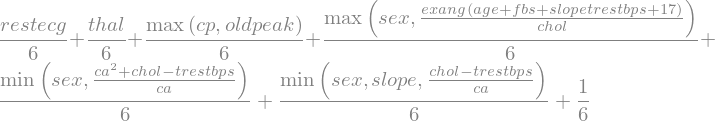

In [22]:
from sympy import init_printing
init_printing()
symplified_best

### 4.1.3 Visualise the winning genetic structure

In [23]:
rename_labels = {
    "add": "+", "sub": "-", "mul": "*",
    "avgval": "avg()", "addval": "+", "mulval": "*",
    "protected_div_zero": "/", "protected_div_one": "/", "protected_div_orig": "/",
    "safe_max": "max", "safe_min": "min",
}
os.makedirs("data", exist_ok=True)
gep.export_expression_tree(best_ind, rename_labels, "data/wids_expression_tree.png")

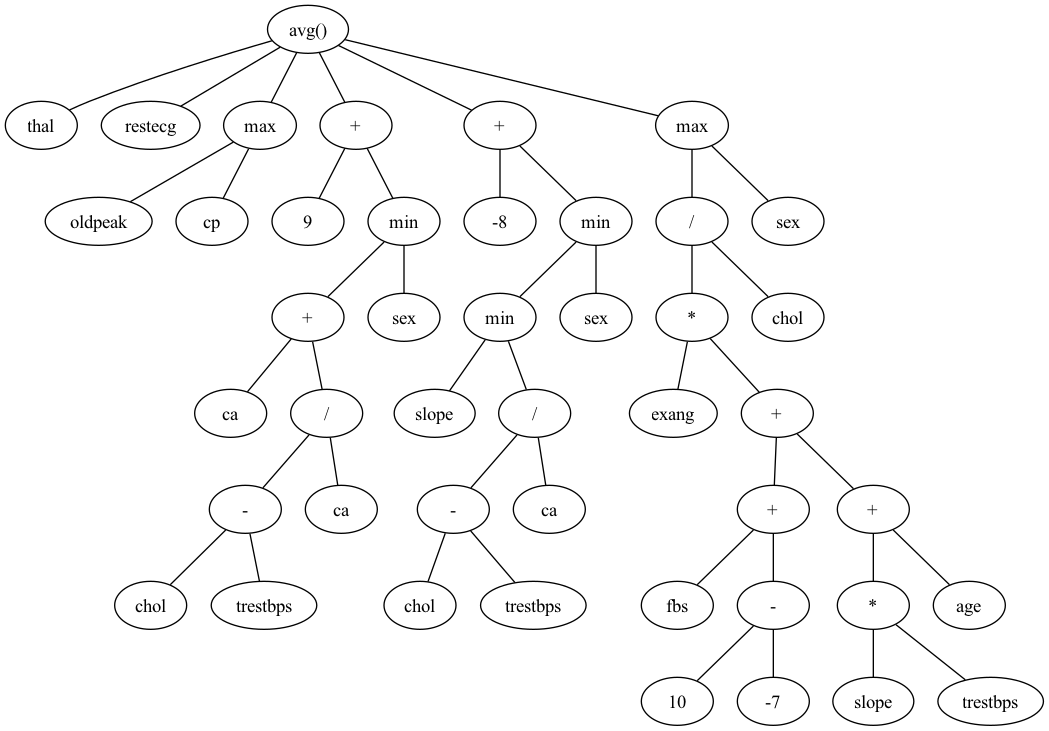

In [24]:
from IPython.display import Image
Image(filename="data/wids_expression_tree.png")

## 4.2 Measure Performance

GEPPY never saw the holdout dataset. Let's apply the model and see how
it generalises.

### 4.2.1 Convert the Model into an Executable Function

This is the classification version of `CalculateGeppyModelOutput` — it
applies linear scaling then sigmoid to return probabilities in [0, 1].

In [25]:
def CalculateGeppyClassifierOutput(testdata, finalTerminals, best_ind, enable_ls=True):
    finalfunc = toolbox.compile(best_ind)

    paramlist = []
    for term in finalTerminals:
        locals()["_holdout" + str(term)] = testdata[term].values
        paramlist = paramlist + ["_holdout" + str(term)]

    ourparam_string = ", ".join(paramlist)
    ourfuncstring = "np.array(list(map(finalfunc, " + ourparam_string + ")))"
    rawoutput = eval(ourfuncstring)

    if enable_ls:
        scaled = best_ind.a * rawoutput + best_ind.b
    else:
        scaled = rawoutput
    return hgh.sigmoid_array(scaled)

### 4.2.2 Pick the decision threshold (J-statistic)

Optimal threshold = the point on the ROC where TPR − FPR is largest.

In [26]:
# Recompute on train, since we may have refit a/b above
train_probs = CalculateGeppyClassifierOutput(train, finalTerminals, best_ind,
                                             settings.enable_linear_scaling)
fpr_t, tpr_t, thr_t = roc_curve(train[target_col].values.astype(int), train_probs)
j_scores = tpr_t - fpr_t
opt_idx = int(np.argmax(j_scores))
best_threshold = float(thr_t[opt_idx])
print(f"Optimal threshold (J-statistic on TRAIN): {best_threshold:.4f}")
print(f"  TPR at this threshold: {tpr_t[opt_idx]:.4f}")
print(f"  FPR at this threshold: {fpr_t[opt_idx]:.4f}")
print(f"  J = TPR - FPR        : {j_scores[opt_idx]:.4f}")
experiment["optimal_threshold"] = best_threshold

Optimal threshold (J-statistic on TRAIN): 0.6292
  TPR at this threshold: 0.7901
  FPR at this threshold: 0.1250
  J = TPR - FPR        : 0.6651


### 4.2.3 Apply the model to holdout and train

In [27]:
for term in finalTarget:
    print("### for the target,", term + ":")
    globals()["holdout_Yt"] = holdout[term].values.astype(int)
    print("setting ", "holdout_Yt")
    globals()["train_Y"] = train[term].values.astype(int)
    print("setting ", "train_Y")

### for the target, target:
setting  holdout_Yt
setting  train_Y


In [28]:
holdout_probs = CalculateGeppyClassifierOutput(
    holdout, finalTerminals, best_ind, settings.enable_linear_scaling
)
holdout_preds = (holdout_probs >= best_threshold).astype(int)

In [29]:
train_probs = CalculateGeppyClassifierOutput(
    train, finalTerminals, best_ind, settings.enable_linear_scaling
)
train_preds = (train_probs >= best_threshold).astype(int)

### 4.2.4 Holdout metrics

In [30]:
def colorful(r, g, b, text):
    return "\033[38;2;{};{};{}m{} \033[38;2;255;255;255m".format(r, g, b, text)

In [31]:
holdout_auc  = roc_auc_score(holdout_Yt, holdout_probs)
holdout_f1   = f1_score(holdout_Yt, holdout_preds, zero_division=0)
holdout_acc  = accuracy_score(holdout_Yt, holdout_preds)
holdout_prec = precision_score(holdout_Yt, holdout_preds, zero_division=0)
holdout_rec  = recall_score(holdout_Yt, holdout_preds, zero_division=0)

head = "\n###################################################"
print(colorful(0, 50, 255, head))
print(colorful(0, 50, 255, " Performance on our holdout dataset is as follows:\n"))
print(colorful(255, 0, 255, f"      AUC       : {holdout_auc:.4f}"))
print(colorful(255, 0, 255, f"      F1        : {holdout_f1:.4f}"))
print(colorful(255, 0, 255, f"      Accuracy  : {holdout_acc:.4f}"))
print(colorful(255, 0, 255, f"      Precision : {holdout_prec:.4f}"))
print(colorful(255, 0, 255, f"      Recall    : {holdout_rec:.4f}"))
print(colorful(255, 0, 255,
    f"      Gene config: head_length={settings.head_length}, "
    f"n_genes={settings.n_genes}, RNC={settings.rnc_array_length}"))
print(colorful(255, 0, 255, f"      Projection : {settings.north_pole_method}"))
print(colorful(0, 50, 255, head))

experiment["holdout_auc"] = float(holdout_auc)
experiment["holdout_f1"] = float(holdout_f1)
experiment["holdout_accuracy"] = float(holdout_acc)
experiment["holdout_precision"] = float(holdout_prec)
experiment["holdout_recall"] = float(holdout_rec)


################################################### 
 Performance on our holdout dataset is as follows:
 
      AUC       : 0.9102 
      F1        : 0.8571 
      Accuracy  : 0.8667 
      Precision : 0.8571 
      Recall    : 0.8571 
      Gene config: head_length=12, n_genes=6, RNC=10 
      Projection : truenorth 

################################################### 


### 4.2.5 Train vs holdout gap — the generalisation check

The reason we have a validation split inside the fitness function is so
evolution can see this gap and shrink it. If train AUC ≫ holdout AUC,
the model overfit; if they're close, it generalised.

In [32]:
train_auc = roc_auc_score(train_Y, train_probs)
train_f1_ = f1_score(train_Y, train_preds, zero_division=0)
train_acc = accuracy_score(train_Y, train_preds)

val_probs = CalculateGeppyClassifierOutput(
    validation, finalTerminals, best_ind, settings.enable_linear_scaling
)
val_preds = (val_probs >= best_threshold).astype(int)
val_Y = validation[target_col].values.astype(int)
val_auc = roc_auc_score(val_Y, val_probs)
val_f1  = f1_score(val_Y, val_preds, zero_division=0)
val_acc = accuracy_score(val_Y, val_preds)

print(f"Train     AUC: {train_auc:.4f}   F1: {train_f1_:.4f}   Acc: {train_acc:.4f}")
print(f"Validation AUC: {val_auc:.4f}   F1: {val_f1:.4f}   Acc: {val_acc:.4f}")
print(f"Holdout   AUC: {holdout_auc:.4f}   F1: {holdout_f1:.4f}   Acc: {holdout_acc:.4f}")
print()
gen_gap = train_auc - holdout_auc
print(f"Generalisation gap (Train AUC − Holdout AUC): {gen_gap:+.4f}")
if abs(gen_gap) < 0.05:
    print("  ↳ small gap — the model generalises well.")
elif gen_gap > 0:
    print("  ↳ positive gap — train > holdout, mild overfitting (this is normal).")
else:
    print("  ↳ negative gap — holdout > train, possibly small samples, possibly luck.")

Train     AUC: 0.8971   F1: 0.8153   Acc: 0.8362
Validation AUC: 0.8733   F1: 0.7692   Acc: 0.8000
Holdout   AUC: 0.9102   F1: 0.8571   Acc: 0.8667

Generalisation gap (Train AUC − Holdout AUC): -0.0131
  ↳ small gap — the model generalises well.


## 4.3 Visualisation of Model Performance

### 4.3.1 ROC curve (holdout)

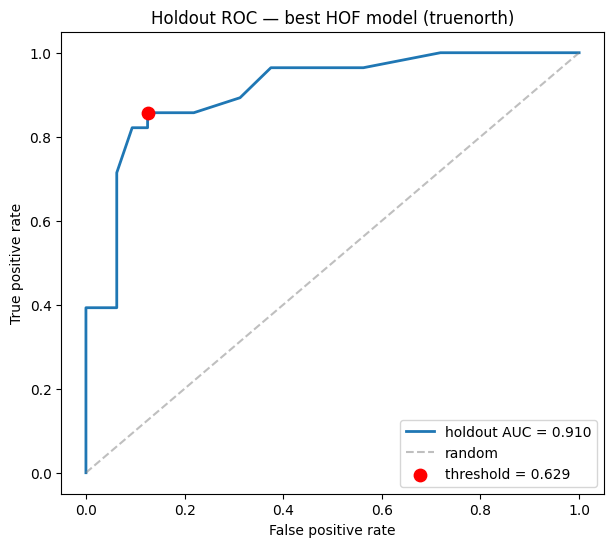

In [33]:
from matplotlib import pyplot

# Compute the holdout ROC curve and locate the (fpr, tpr) closest to our
# chosen decision threshold — the train threshold maps to a different index
# range on the holdout curve, so we search inside it directly.
fpr, tpr, thr = roc_curve(holdout_Yt, holdout_probs)
marker_idx = int(np.argmin(np.abs(thr - best_threshold)))

pyplot.rcParams["figure.figsize"] = [7, 6]
pyplot.figure()
pyplot.plot(fpr, tpr, lw=2, label=f"holdout AUC = {holdout_auc:.3f}")
pyplot.plot([0, 1], [0, 1], "--", color="grey", alpha=0.5, label="random")
pyplot.scatter([fpr[marker_idx]], [tpr[marker_idx]],
               s=80, c="red", zorder=5, label=f"threshold = {best_threshold:.3f}")
pyplot.xlabel("False positive rate")
pyplot.ylabel("True positive rate")
pyplot.title(f"Holdout ROC — best HOF model ({settings.north_pole_method})")
pyplot.legend(loc="lower right")
pyplot.show()

### 4.3.2 Precision–Recall curve

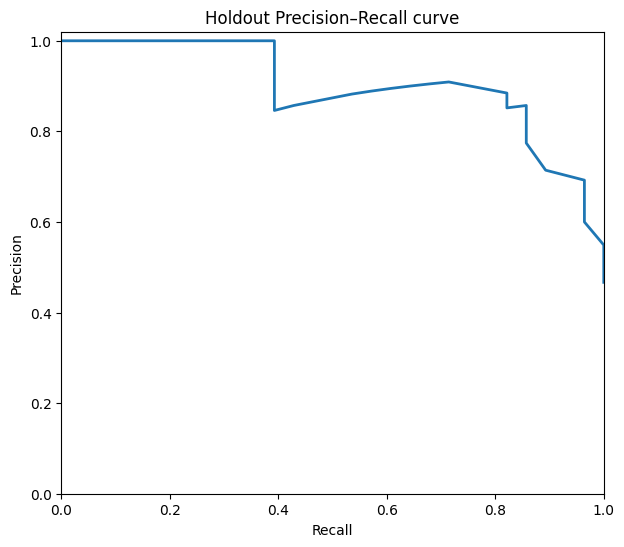

In [34]:
prec_curve, rec_curve, _ = precision_recall_curve(holdout_Yt, holdout_probs)
pyplot.rcParams["figure.figsize"] = [7, 6]
pyplot.figure()
pyplot.plot(rec_curve, prec_curve, lw=2)
pyplot.xlabel("Recall")
pyplot.ylabel("Precision")
pyplot.title("Holdout Precision–Recall curve")
pyplot.xlim(0, 1)
pyplot.ylim(0, 1.02)
pyplot.show()

### 4.3.3 Confusion matrix (holdout)

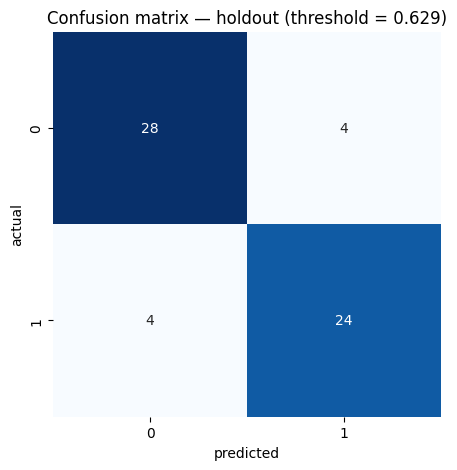

In [35]:
cm = confusion_matrix(holdout_Yt, holdout_preds)
pyplot.rcParams["figure.figsize"] = [5, 5]
pyplot.figure()
sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues")
pyplot.xlabel("predicted")
pyplot.ylabel("actual")
pyplot.title(f"Confusion matrix — holdout (threshold = {best_threshold:.3f})")
pyplot.show()

### 4.3.4 Predicted probability distribution by true class

If the classifier is calibrated, positives cluster near 1 and negatives
near 0. Overlap in the middle is where the threshold matters.

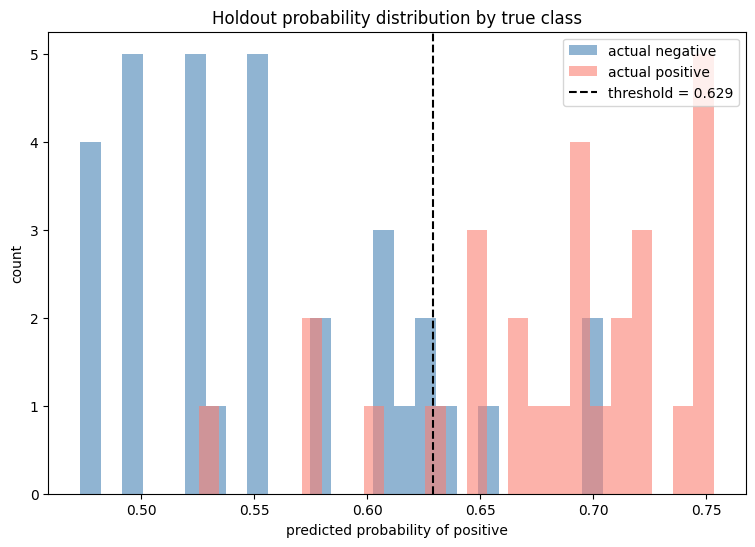

In [36]:
pyplot.rcParams["figure.figsize"] = [9, 6]
pyplot.figure()
pyplot.hist(holdout_probs[holdout_Yt == 0], bins=25, alpha=0.6,
            color="steelblue", label="actual negative")
pyplot.hist(holdout_probs[holdout_Yt == 1], bins=25, alpha=0.6,
            color="salmon", label="actual positive")
pyplot.axvline(best_threshold, color="black", linestyle="--",
               label=f"threshold = {best_threshold:.3f}")
pyplot.xlabel("predicted probability of positive")
pyplot.ylabel("count")
pyplot.title("Holdout probability distribution by true class")
pyplot.legend()
pyplot.show()

### 4.3.5 Train vs Holdout probability distributions — overfit check

Side-by-side histograms of the model's output on train (blue) vs holdout
(green). Shapes should be similar; if train is much sharper / spikier
than holdout, the model has memorised the training set.

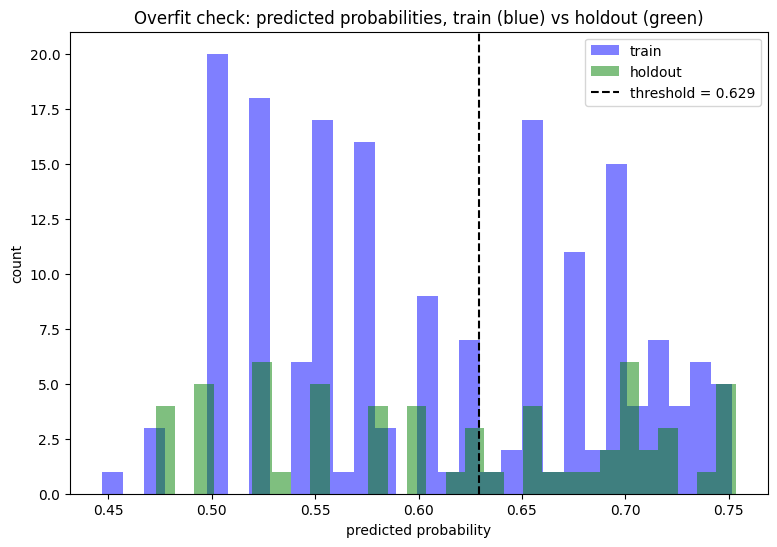

In [37]:
pyplot.rcParams["figure.figsize"] = [9, 6]
pyplot.figure()
pyplot.hist(train_probs, bins=30, color="blue", alpha=0.5, label="train")
pyplot.hist(holdout_probs, bins=30, color="green", alpha=0.5, label="holdout")
pyplot.axvline(best_threshold, color="black", linestyle="--",
               label=f"threshold = {best_threshold:.3f}")
pyplot.xlabel("predicted probability")
pyplot.ylabel("count")
pyplot.title("Overfit check: predicted probabilities, train (blue) vs holdout (green)")
pyplot.legend()
pyplot.show()

# 5. Deployment

### Is it worth implementing the answer?

Deploying ML to production costs money. Doing nothing — predicting the
**majority class** on every row — is the cheap baseline. Let's quantify
how much better the evolved model is.

### How bad is the majority-class baseline?

In [38]:
majority = int(train_Y.mean() > 0.5)  # the more-common class in train
baseline_preds = np.full(len(holdout_Yt), majority, dtype=int)
baseline_acc = accuracy_score(holdout_Yt, baseline_preds)
baseline_f1  = f1_score(holdout_Yt, baseline_preds, zero_division=0)
baseline_prec = precision_score(holdout_Yt, baseline_preds, zero_division=0)
baseline_rec  = recall_score(holdout_Yt, baseline_preds, zero_division=0)

print(f"Majority-class baseline ({'positive' if majority else 'negative'}):")
print(f"  Accuracy : {baseline_acc:.4f}")
print(f"  F1       : {baseline_f1:.4f}")
print(f"  Precision: {baseline_prec:.4f}")
print(f"  Recall   : {baseline_rec:.4f}")

Majority-class baseline (negative):
  Accuracy : 0.5333
  F1       : 0.0000
  Precision: 0.0000
  Recall   : 0.0000


## 5.1 Business Value Assessment

Side-by-side bar chart: orange = "do nothing" (majority class);
green = our evolved model.

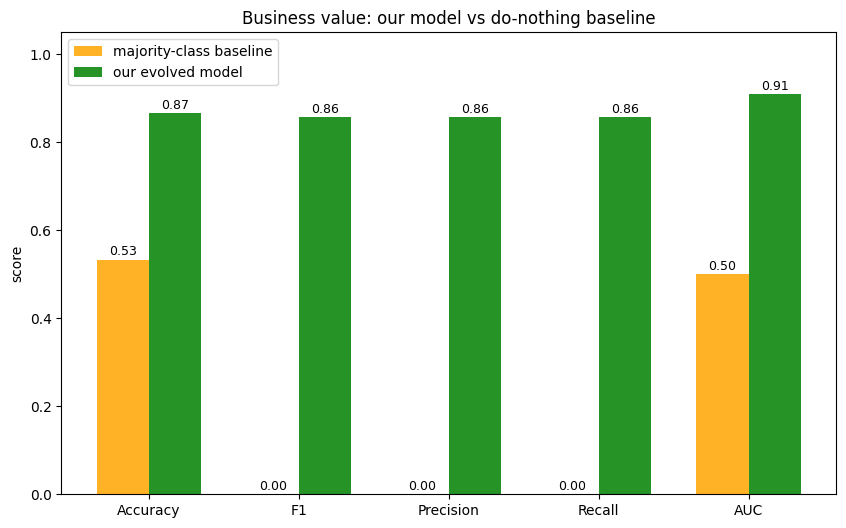

In [39]:
import matplotlib.pyplot as plt2

metrics_labels = ["Accuracy", "F1", "Precision", "Recall", "AUC"]
ours = [holdout_acc, holdout_f1, holdout_prec, holdout_rec, holdout_auc]
base = [baseline_acc, baseline_f1, baseline_prec, baseline_rec, 0.5]

x = np.arange(len(metrics_labels))
width = 0.35

plt2.rcParams["figure.figsize"] = [10, 6]
fig, ax = plt2.subplots()
ax.bar(x - width / 2, base, width, color="orange", alpha=0.85, label="majority-class baseline")
ax.bar(x + width / 2, ours, width, color="green",  alpha=0.85, label="our evolved model")
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.set_title("Business value: our model vs do-nothing baseline")
ax.legend()
for bar, val in zip(ax.containers, [base, ours]):
    for rect, v in zip(bar, val):
        ax.annotate(f"{v:.2f}", xy=(rect.get_x() + rect.get_width() / 2, v),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9)
plt2.show()

## 5.2 Next Steps: Implementation

The symbolic logistic regression deploys as a tiny pipeline:

1. evaluate the simplified expression on the inputs,
2. multiply by `a` and add `b`,
3. pass through a sigmoid,
4. compare to the threshold to emit 0/1.

That's a handful of arithmetic operations — drop it into a spreadsheet,
stored procedure, edge device, or any target language with very little
effort. A huge advantage over opaque models that need their full training
stack to deploy.

# 6. HFF-specific reporting

Sections below are unique to the v1.0.4 notebook — they show what the
multi-objective HFF fitness gives us *beyond* the standard AUC story.

## 6.1 Hall-of-Fame reranking via HFF

Every HOF model rescored on a richer metric vector via
`hff.calculate_fitness_hf1_enhanced`, surfacing the train/val balance
trade-off explicitly.

In [40]:
ranked = hgh.rerank_hof_classification(
    hof, train, validation, target_col, finalTerminals, toolbox, settings
)
print(f"\nTop 10 HOF models by HFF angular distance (north_pole={settings.north_pole_method}):")
print(ranked.head(10)[[
    "model", "length",
    "train_auc", "val_auc",
    "train_f1", "val_f1",
    "threshold", "angular_distance",
]].to_string(index=False))


Top 10 HOF models by HFF angular distance (north_pole=truenorth):
 model  length  train_auc  val_auc  train_f1   val_f1  threshold  angular_distance
     0      44   0.897055 0.873326  0.815287 0.769231   0.629198          0.246156
    27      44   0.897055 0.873326  0.815287 0.769231   0.629198          0.246156
    26      44   0.897055 0.873326  0.815287 0.769231   0.629198          0.246156
    25      44   0.897055 0.873326  0.815287 0.769231   0.629198          0.246156
    24      44   0.897055 0.873326  0.815287 0.769231   0.629198          0.246156
    23      44   0.897055 0.873326  0.815287 0.769231   0.629198          0.246156
    22      42   0.897055 0.873326  0.815287 0.769231   0.629198          0.246156
    21      44   0.897055 0.873326  0.815287 0.769231   0.629198          0.246156
    20      46   0.897055 0.873326  0.815287 0.769231   0.629198          0.246156
    19      44   0.897055 0.873326  0.815287 0.769231   0.629198          0.246156


## 6.2 Set-level HIGD diagnostic

How well does the HOF as a *set* cover the holdout? Lower HIGD = the
HOF's residuals are uniformly distributed on the angular sphere
(no directional bias).

In [41]:
higd_score = hgh.holdout_higd_diagnostic(
    hof, holdout, target_col, finalTerminals, toolbox, settings, task="classification"
)
print(f"HIGD (holdout, n_ref={settings.higd_reference_points}, dims={len(holdout)}): {higd_score:.6f}")
experiment["holdout_higd"] = float(higd_score) if not math.isnan(higd_score) else None

HIGD (holdout, n_ref=10000, dims=60): 0.498636


## 6.3 Save experiment record

In [42]:
import json
print(json.dumps(experiment, sort_keys=False, indent=4, default=str))

{
    "date": "2026/05/19",
    "seed": "5",
    "task": "binary classification",
    "north_pole_method": "truenorth",
    "splits": {
        "train": 177,
        "validation": 60,
        "holdout": 60
    },
    "final_terminal_inputs": [
        "age",
        "sex",
        "cp",
        "trestbps",
        "chol",
        "fbs",
        "restecg",
        "thalach",
        "exang",
        "oldpeak",
        "slope",
        "ca",
        "thal"
    ],
    "head_length": "12",
    "n_genes": "6",
    "rnc_array_length": "10",
    "tournament size": "4",
    "population size": "58",
    "number of elites": "2",
    "number of generations": "200",
    "number of islands": "3",
    "migration FREQ": "40",
    "optimal_threshold": 0.6291977660295056,
    "holdout_auc": 0.91015625,
    "holdout_f1": 0.8571428571428571,
    "holdout_accuracy": 0.8666666666666667,
    "holdout_precision": 0.8571428571428571,
    "holdout_recall": 0.8571428571428571,
    "holdout_higd": 0.498636474817

# A/B the projection methods

**What the paper claims.** Classical Pareto-based multi-objective methods
(NSGA-II, NSGA-III, MOEA/D, …) work well when the number of objectives is
small, but break down as that number grows: with many objectives almost
every solution is non-dominated, the Pareto front loses discriminative
power, and the optimiser stops getting a useful selection signal. HFF
sidesteps this by projecting the objective vector onto a unit hypersphere
and reducing it to a **single scalar** — angular distance to a reference
pole — that scales naturally with objective count.

**What we are *not* claiming.** We are not claiming HFF beats
single-objective AUC. We're solving a different problem: when you
genuinely have multiple objectives (here: AUC + F1 + accuracy, all on
both train and validation), HFF gives you a principled scalar fitness
that doesn't suffer the dominance-degeneration that hits Pareto methods
at high dimensionality.

**Useful at small dimensions too.** The hyperspherical formulation works
at any objective count. With 2–3 objectives it's a clean alternative to
weighted sums; with 10+ it's a way to keep evolution working at all.

To A/B the two projection methods, change `settings.north_pole_method`
in the settings cell at the top:

- `"truenorth"` (default) — pole in an augmented space at `(0,…,0,1)`;
  reduces angular distance as the metric magnitudes push toward "perfect
  on every axis". Combined with the train+validation split inside the
  fitness, this naturally selects against overfit.
- `"balanced"` — pole at `(1/√m, …, 1/√m)`. Measures *direction only*:
  a model with all metrics equal (regardless of magnitude) sits on the
  pole. Useful as a contrast — overfit models that are great on train
  but mediocre on val show up as off-pole imbalance.

Re-run end to end and compare:
- the simplified expression
- holdout AUC / F1 / accuracy
- the generalisation gap (train − holdout)
- the HOF reranker table in section 6.1

# 7. Credits & Licence

**MIT** | Author: **Andrew Morgan** | Built on top of geppy + DEAP + the
HFF Rust library.